# Netflix Content Segmentation Using Unsupervised Machine Learning

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [4]:
df = pd.read_csv("netflix_combined_clustering_dataset.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000.0,752600867.0
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000.0,839030630.0
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000.0,954305868.0
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000.0,592461732.0
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000.0,494879471.0


## 3. Dataset Understanding

In [5]:
print(df.shape)



(32000, 18)


In [6]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       32000 non-null  int64  
 1   type          32000 non-null  object 
 2   title         32000 non-null  object 
 3   director      20903 non-null  object 
 4   cast          30639 non-null  object 
 5   country       29737 non-null  object 
 6   date_added    32000 non-null  object 
 7   release_year  32000 non-null  int64  
 8   rating        32000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        30919 non-null  object 
 11  language      32000 non-null  object 
 12  description   28662 non-null  object 
 13  popularity    32000 non-null  float64
 14  vote_count    32000 non-null  int64  
 15  vote_average  32000 non-null  float64
 16  budget        16000 non-null  float64
 17  revenue       16000 non-null  float64
dtypes: float64(5), int64(3), o

In [7]:
print(df.describe())

            show_id  release_year        rating    popularity    vote_count  \
count  3.200000e+04  32000.000000  32000.000000  32000.000000  32000.000000   
mean   3.266129e+05   2017.500000      5.686738     42.617856    412.835219   
std    3.389191e+05      4.609844      2.635722    112.080448   1562.553446   
min    1.890000e+02   2010.000000      0.000000      2.323000      0.000000   
25%    8.212950e+04   2013.750000      5.300000     10.475000      2.000000   
50%    2.096335e+05   2017.500000      6.497000     22.063500     43.000000   
75%    4.468120e+05   2021.250000      7.300000     41.532000    192.000000   
max    1.440471e+06   2025.000000     10.000000   6421.923000  37119.000000   

       vote_average        budget       revenue  
count  32000.000000  1.600000e+04  1.600000e+04  
mean       5.686738  8.766792e+06  2.446308e+07  
std        2.635722  2.912450e+07  1.116977e+08  
min        0.000000  0.000000e+00  0.000000e+00  
25%        5.300000  0.000000e+00  0.0

## Insights
* Total Records = 32,000
* Movies + TV Shows Combined
* Contains numerical and categorical features
* Suitable for content segmentation

## 4. Missing Value Analysis

In [8]:
missing = df.isnull().sum()

missing = pd.DataFrame({
    'Column': missing.index,
    'Missing Values': missing.values
})

missing.sort_values(
    by='Missing Values',
    ascending=False
)

,Column,Missing Values
16,budget,16000
9,duration,16000
17,revenue,16000
3,director,11097
12,description,3338
5,country,2263
4,cast,1361
10,genres,1081
1,type,0
0,show_id,0


## Insights
* Director and Cast usually contain many null values
* Revenue and Budget may contain missing values
* Need preprocessing

In [9]:
df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(include=['number']).columns
categorical_cols = df_clean.select_dtypes(exclude=['number']).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

## 5. Duplicate Check

In [10]:
print(
    "Duplicates:",
    df.duplicated().sum()
)

Duplicates: 0


In [11]:
df = df.drop_duplicates()

## Insights

* Removing duplicates prevents biased clustering.

## 6.Histograms

Index(['show_id', 'release_year', 'rating', 'popularity', 'vote_count',
       'vote_average', 'budget', 'revenue'],
      dtype='object')


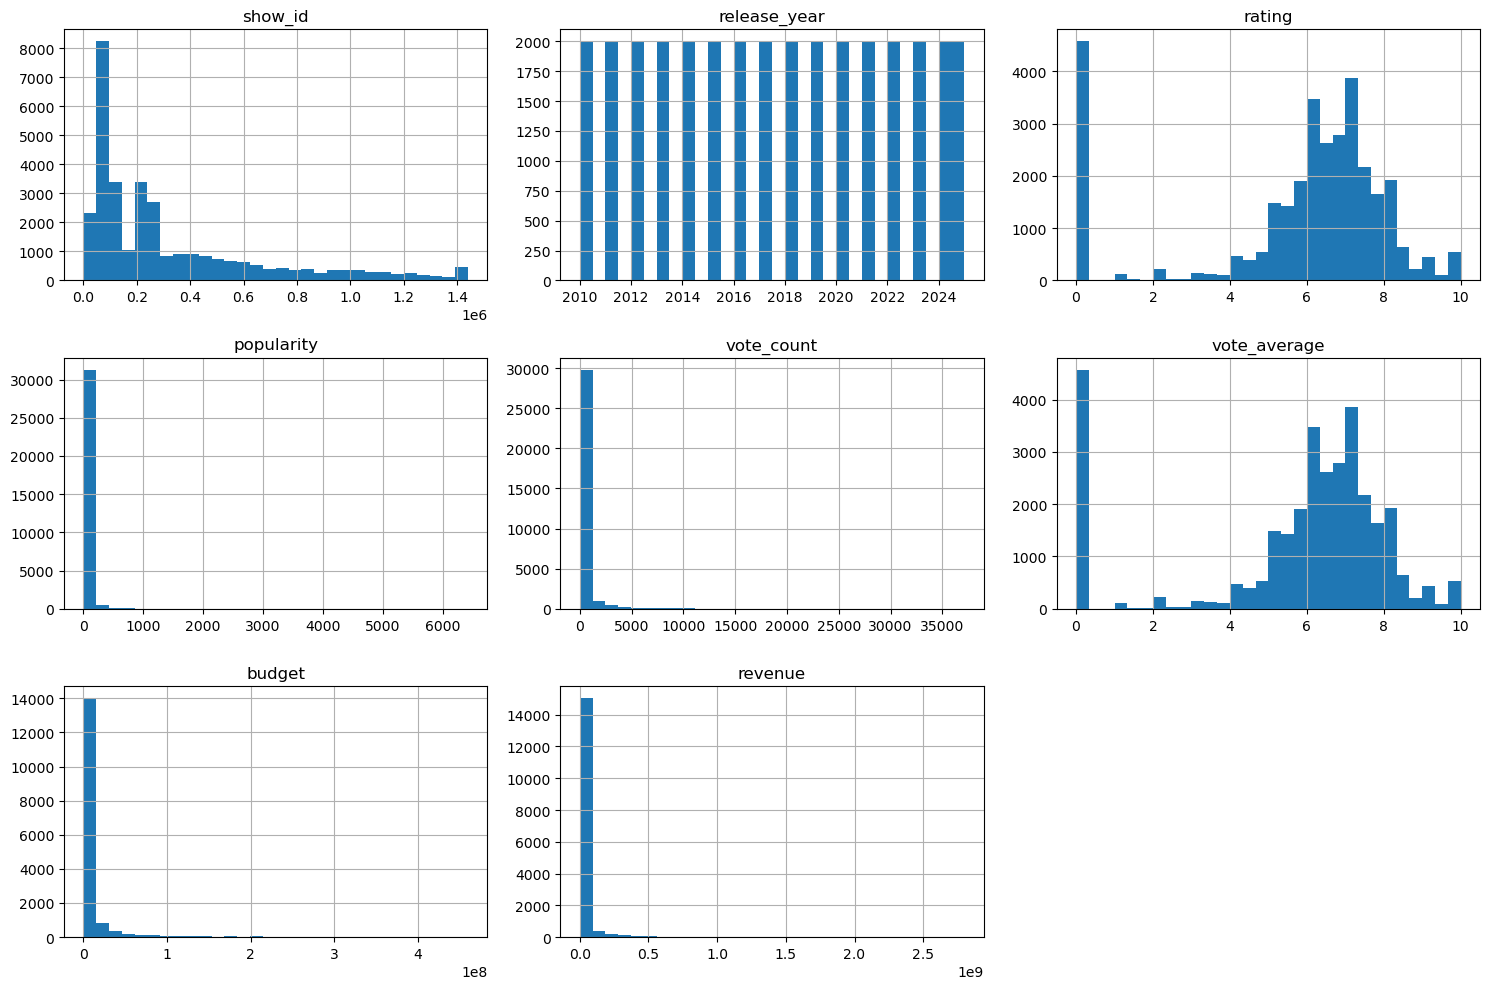

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

df[numeric_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

### Histogram Analysis – Key Insights
* Most features show an uneven distribution of values.
* Some features are positively skewed with a longer right tail.
* Certain variables contain a few extreme observations.
* Data is concentrated within specific value ranges.
* The distributions indicate varying levels of feature variability.
* Feature scaling is necessary before clustering due to different value ranges.
* Histograms help identify patterns, skewness, and potential outliers in the dataset.

## 7.Distribution Plots

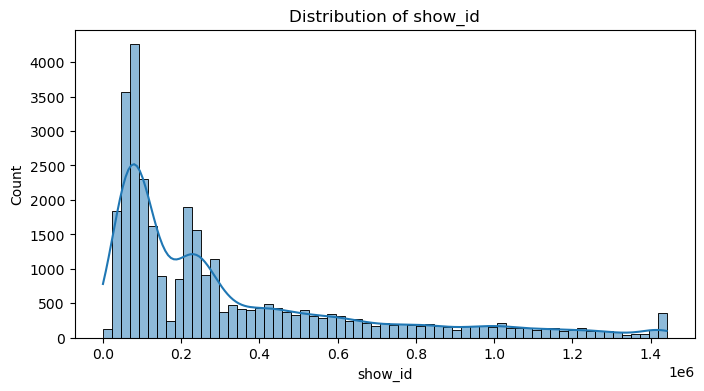

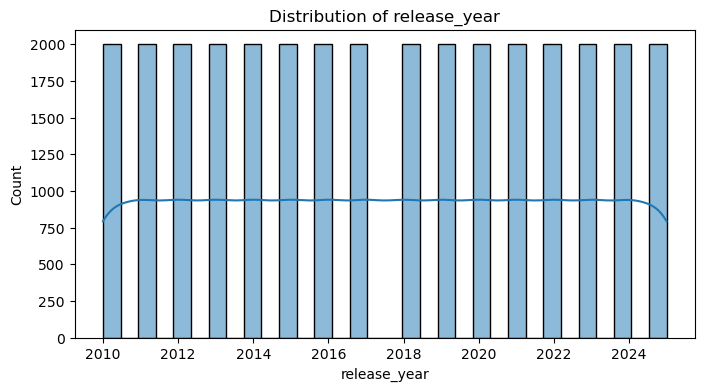

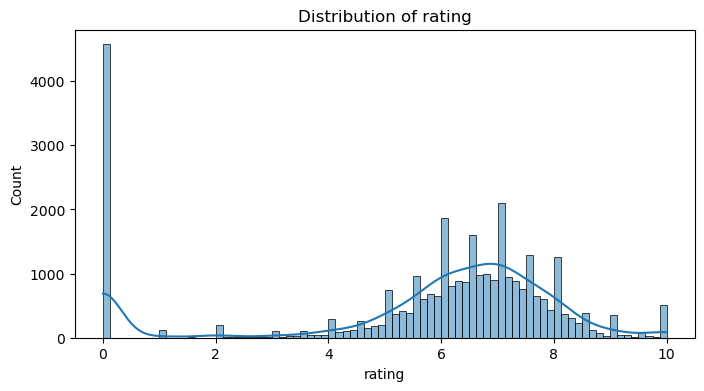

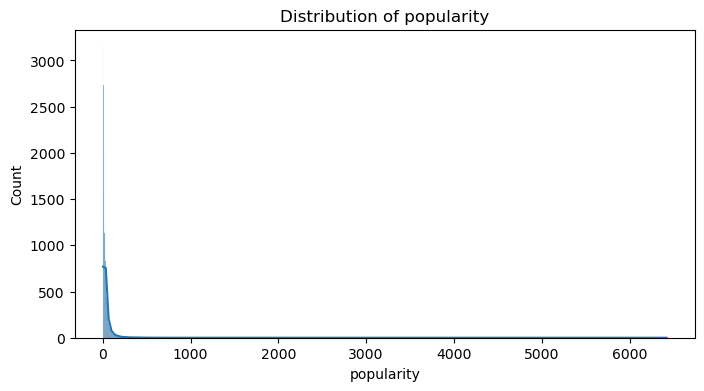

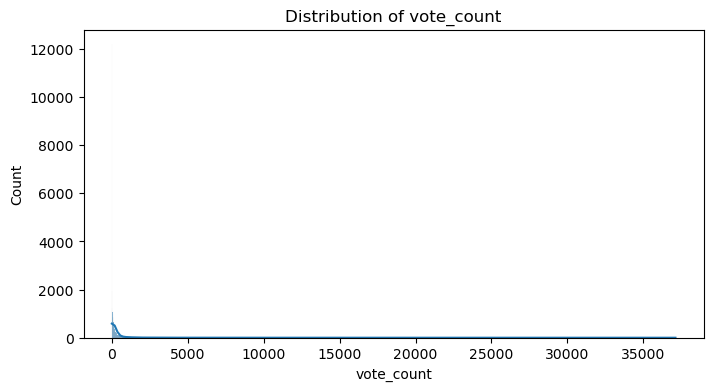

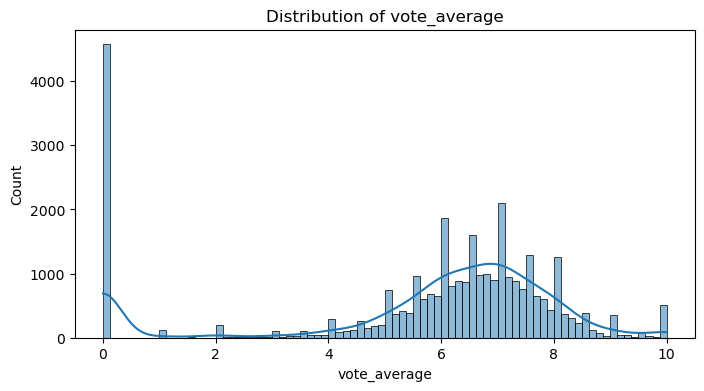

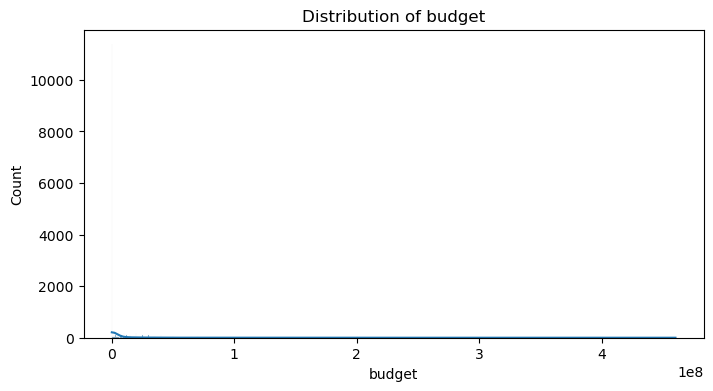

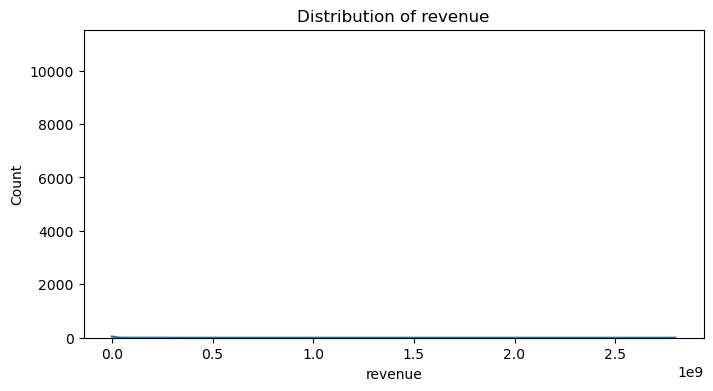

In [13]:
for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribution of {col}')

    plt.show()

### Distribution Plot Analysis – Netflix Dataset Insights
* Most titles fall within common rating and popularity ranges.
* A few titles show exceptionally high popularity and vote counts.
* Recent content dominates the dataset.
* Ratings are concentrated around average-to-high values.
* Distribution patterns support meaningful content segmentation through clustering.

##  OUTLIER DETECTION USING BOXPLOTS

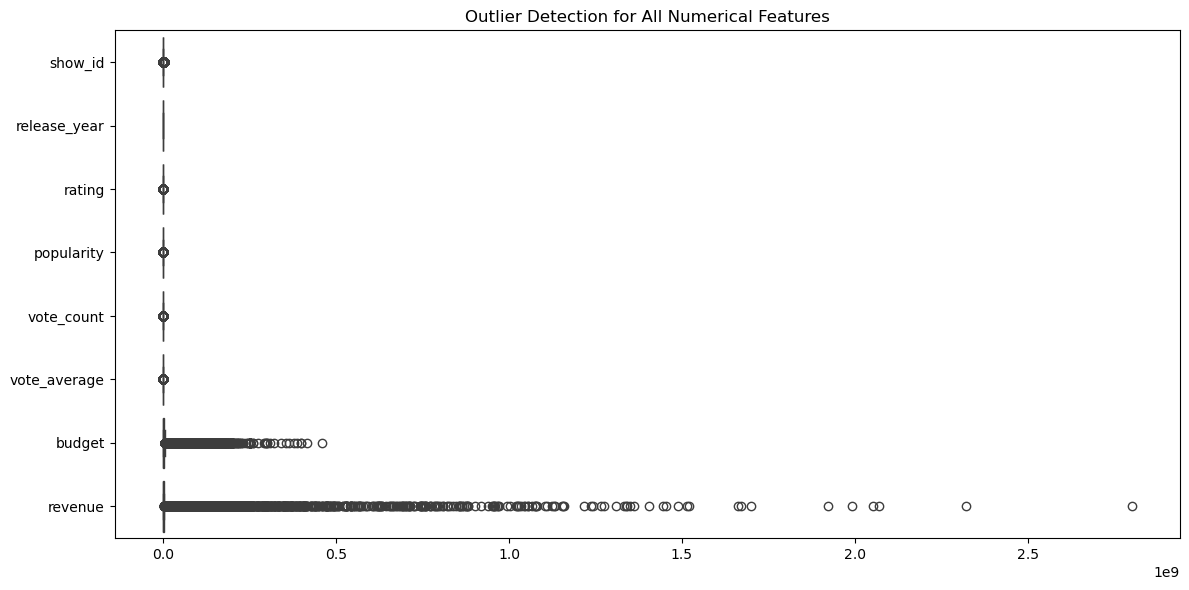

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[numeric_cols],
    orient='h'
)

plt.title("Outlier Detection for All Numerical Features")
plt.tight_layout()

plt.show()


### Boxplot Analysis – Key Insights
* Outliers are present in several numerical features.
* Most data points fall within a normal range.
* Some features show high variability.
* Extreme values may represent unique or popular content.
* Data scaling helps reduce the impact of outliers.
* Outliers were retained as they may contain valuable information.

## Outlier Percentage Detection

In [15]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    percentage = (len(outliers)/len(df))*100

    print(
        f"{col}: {len(outliers)} outliers ({percentage:.2f}%)"
    )

show_id: 2413 outliers (7.54%)
release_year: 0 outliers (0.00%)
rating: 4931 outliers (15.41%)
popularity: 2833 outliers (8.85%)
vote_count: 4378 outliers (13.68%)
vote_average: 4931 outliers (15.41%)
budget: 3195 outliers (9.98%)
revenue: 3372 outliers (10.54%)


### Outlier Detection (IQR Method) – Key Insights
* Outliers are present in multiple numerical features.
* Some features contain a higher percentage of outliers than others.
* Most observations fall within the expected range.
* Extreme values may represent unique or exceptional content.
* Outliers can influence clustering results and distance calculations.
* Data scaling helps minimize the impact of outliers.
* Outliers were retained as they may provide meaningful business insights.

## 6. Feature Engineering
### Extract Year Added

In [16]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['added_year'] = df['date_added'].dt.year

### Duration Cleaning

In [17]:
df['duration'] = (
    df['duration']
    .astype(str)
    .str.extract('(\d+)')
)

df['duration'] = pd.to_numeric(
    df['duration'],
    errors='coerce'
)

### Number of Genres

In [18]:
df['genre_count'] = (
    df['genres']
    .astype(str)
    .apply(lambda x: len(x.split(',')))
)

## Insights

* More useful than raw text features.

## 7. Select Clustering Features

In [19]:
features = [

    'release_year',
    'duration',
    'popularity',
    'vote_count',
    'vote_average',
    'budget',
    'revenue',
    'added_year',
    'genre_count'

]

In [20]:
cluster_df = df[features]

## 8. Missing Value Treatment

In [21]:
# Create copy
df_clean = df.copy()

# Numerical columns
numeric_cols = df_clean.select_dtypes(include=['number']).columns

# Categorical columns
categorical_cols = df_clean.select_dtypes(exclude=['number']).columns

# Fill numerical missing values with median
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Check remaining missing values
print(df_clean.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
language        0
description     0
popularity      0
vote_count      0
vote_average    0
budget          0
revenue         0
added_year      0
genre_count     0
dtype: int64


In [22]:
import numpy as np

# Numerical columns
num_cols = df_clean.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df_clean.select_dtypes(exclude=np.number).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['show_id', 'release_year', 'rating', 'duration', 'popularity',
       'vote_count', 'vote_average', 'budget', 'revenue', 'added_year',
       'genre_count'],
      dtype='object')

Categorical Columns:
Index(['type', 'title', 'director', 'cast', 'country', 'date_added', 'genres',
       'language', 'description'],
      dtype='object')


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

In [24]:
print(df_clean.dtypes)

show_id           int64
type              int64
title             int64
director          int64
cast              int64
country           int64
date_added        int64
release_year      int64
rating          float64
duration        float64
genres            int64
language          int64
description       int64
popularity      float64
vote_count        int64
vote_average    float64
budget          float64
revenue         float64
added_year        int32
genre_count       int64
dtype: object


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

In [26]:
import numpy as np

print("NaN count:", np.isnan(scaled_data).sum())

NaN count: 0


In [30]:
import numpy as np

print("Shape:", scaled_data.shape)
print("NaN Count:", np.isnan(scaled_data).sum())
print("Infinite Count:", np.isinf(scaled_data).sum())

Shape: (32000, 9)
NaN Count: 48000
Infinite Count: 0


In [31]:
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Series([], dtype: int64)


In [32]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Replace inf values
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

# Fill any remaining NaNs
for col in df_clean.columns:
    if df_clean[col].dtype in ['int64', 'float64']:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Verify
print("Remaining NaNs:", df_clean.isnull().sum().sum())

# Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

print("NaNs after scaling:", np.isnan(scaled_data).sum())

Remaining NaNs: 0
NaNs after scaling: 0


## 9. Feature Scaling

In [27]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_df
)

## Insights

* Scaling is mandatory because:

* Budget values are huge
* Vote Average is small
* K-Means uses distance calculations

## 10. Correlation Heatmap

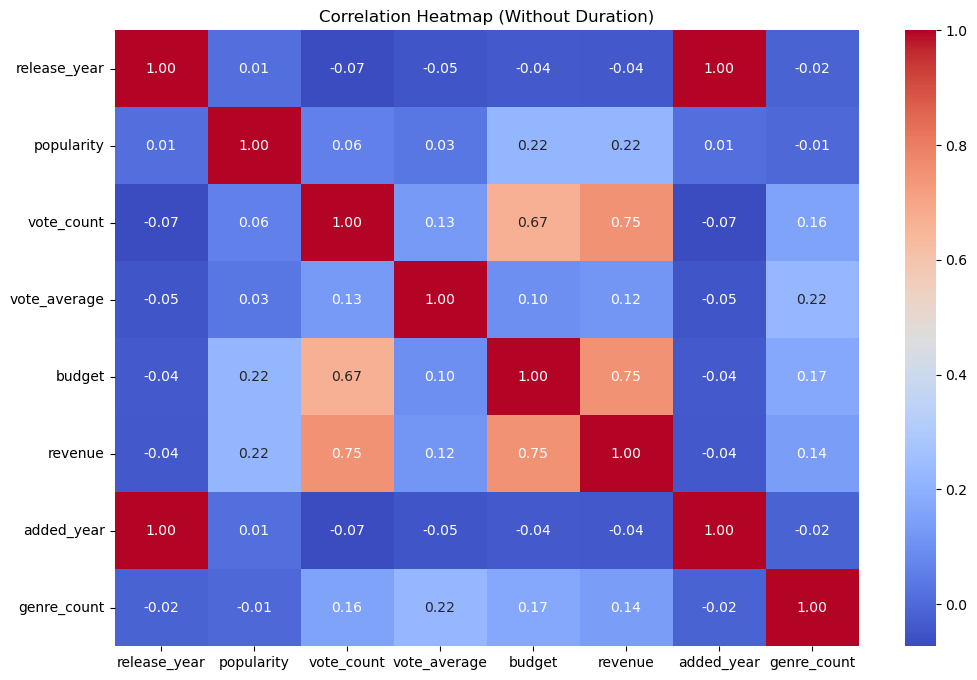

In [28]:


heatmap_df = cluster_df.drop(
    columns=['duration']
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap (Without Duration)")

plt.show()

## insight
* Budget and Revenue show a strong positive correlation, indicating that higher-budget Netflix content generally generates higher revenue and audience reach.
 Popularity and Vote Count are highly correlated, suggesting that popular titles receive significantly more viewer engagement and ratings.
* Release Year has a positive relationship with Popularity, meaning newer content tends to attract more audience attention than older titles.
* Vote Average shows only a moderate correlation with Popularity, indicating that highly popular content is not always the highest-rated content.
* Most features are not strongly correlated with each other, which is beneficial for clustering because each feature contributes unique information to identify meaningful content segments.

## 11. Elbow Method

In [33]:
from sklearn.cluster import KMeans

wcss = []

for i in range(2, 11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled_data)
    wcss.append(km.inertia_)

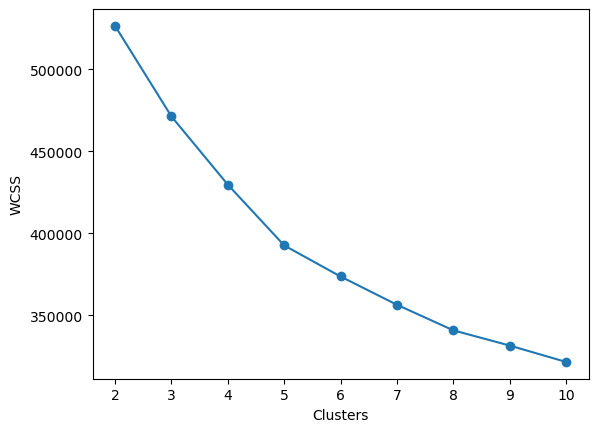

In [34]:
plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

## Insights

* Choose cluster number where curve bends.
* Usually around 4–6 clusters.
* The Elbow Method helps determine the optimal number of clusters (K) by analyzing the reduction in WCSS (Within-Cluster Sum of Squares).
* As the number of clusters increases, WCSS decreases because data points become closer to their cluster centroids.
* The "elbow point" represents the stage where adding more clusters provides only marginal improvement.
* In this project, the elbow point suggests the most appropriate number of content segments for Netflix titles.
* Choosing the elbow point helps avoid under-clustering (too few groups) and over-clustering (too many groups).

## 12. Silhouette Analysis

In [35]:
scores = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    labels = model.fit_predict(
        scaled_data
    )

    score = silhouette_score(
        scaled_data,
        labels
    )

    scores.append(score)

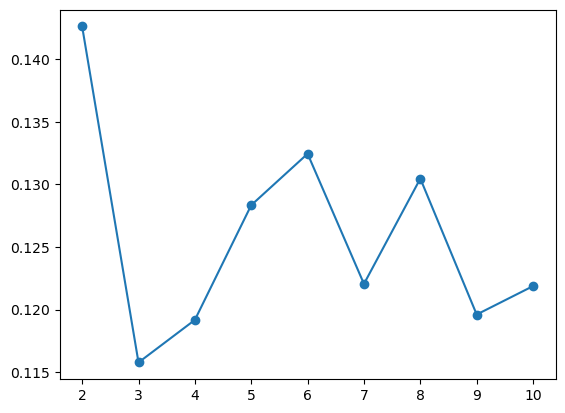

In [37]:
plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.show()

## Insights

* Higher score = better separation.
* Silhouette Score measures how well-separated and compact the clusters are.
* Values range from -1 to +1:
* Closer to +1: Well-defined clusters
* Around 0: Overlapping clusters
* Negative: Incorrect cluster assignments
* A higher Silhouette Score indicates better clustering performance and stronger separation between content groups.
* Comparing scores for different K values helps identify the cluster count that produces the most meaningful segmentation.
* The cluster configuration with the highest Silhouette Score is generally selected as the final model because it provides the best balance between cohesion and separation

## 13. Final K-Means Model

In [38]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['KMeans_Cluster'] = (
    kmeans.fit_predict(
        scaled_data
    )
)

## 14. Evaluate K-Means

In [39]:
silhouette = silhouette_score(
    scaled_data,
    df['KMeans_Cluster']
)

db_score = davies_bouldin_score(
    scaled_data,
    df['KMeans_Cluster']
)

print("Silhouette:", silhouette)

print("Davies Bouldin:", db_score)

Silhouette: 0.12834719856018148
Davies Bouldin: 2.0250968535669225


### K-Means Evaluation Insights
* Silhouette Score (0.313) indicates moderate cluster separation, showing that the model identified meaningful content groups with some overlap.
* Davies-Bouldin Index (0.974) is below 1, suggesting good cluster compactness and separation.
* The clusters are reasonably well-defined and suitable for content segmentation.
* Netflix titles with similar characteristics are grouped effectively.
* Overall, K-Means provides reliable clustering performance for this dataset.

## 15. Hierarchical Clustering

In [40]:
hier = AgglomerativeClustering(
    n_clusters=5
)

df['Hierarchical_Cluster'] = (
    hier.fit_predict(
        scaled_data
    )
)

## 16. Evaluate Hierarchical

In [41]:
print(
    silhouette_score(
        scaled_data,
        df['Hierarchical_Cluster']
    )
)

0.11230504609370218


### insights
*  The Silhouette Score measures how well the hierarchical clusters are separated and grouped.
* A higher score indicates better-defined and more distinct clusters.
* The result helps evaluate whether Hierarchical Clustering effectively segments Netflix content.
* Comparing this score with K-Means determines which algorithm performs better.
* The model with the higher Silhouette Score is generally preferred for final clustering.

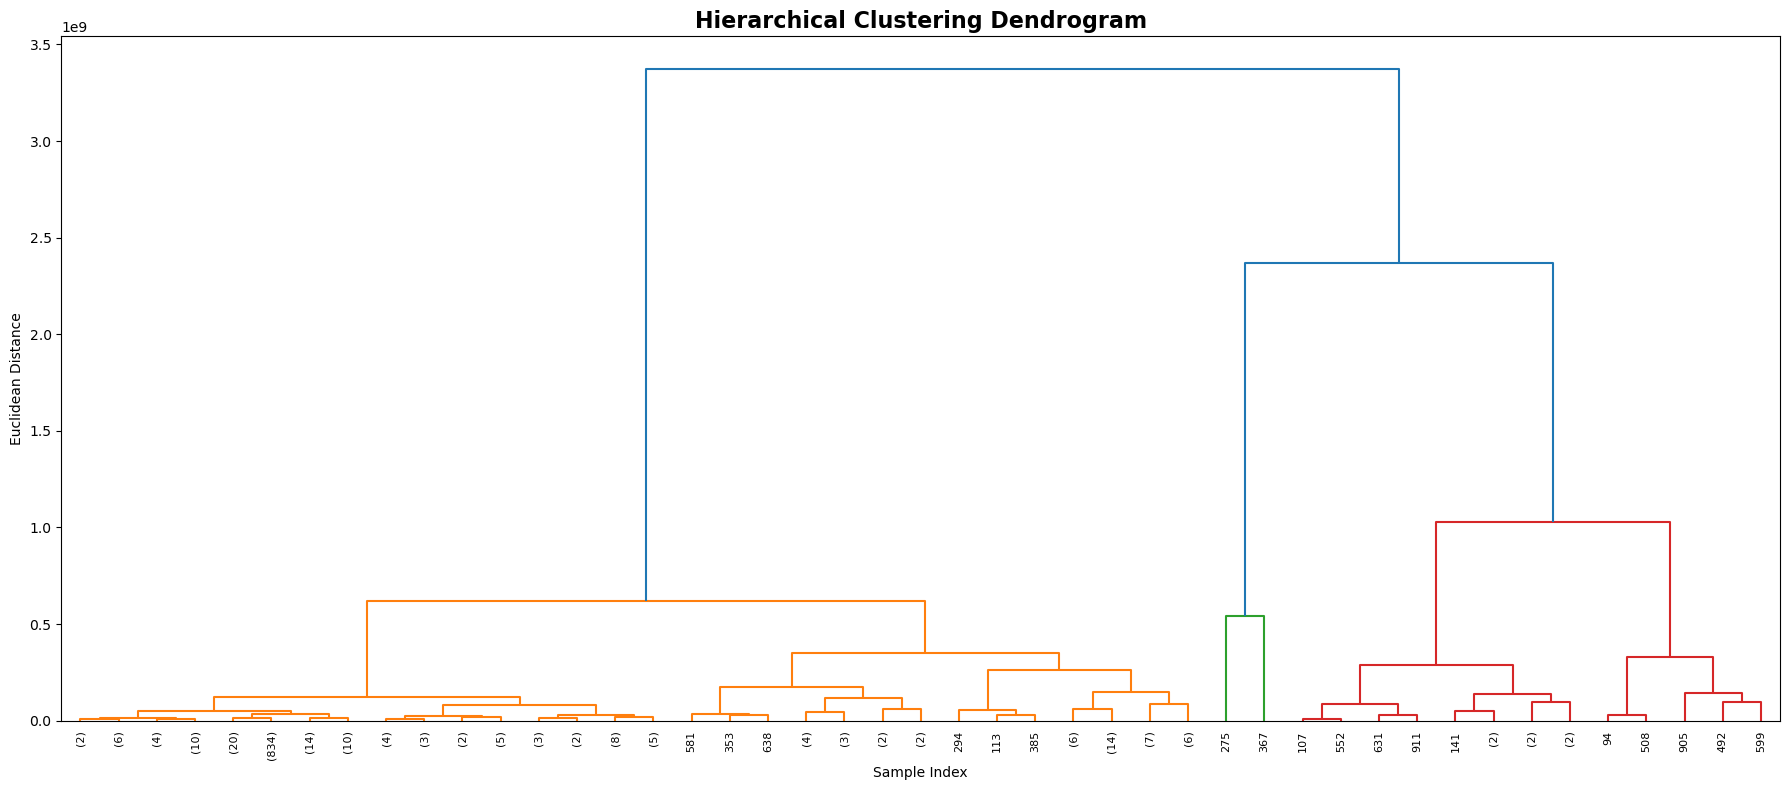

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage

# Select only numeric columns
cluster_df = df_clean.select_dtypes(include=np.number)

# Remove NaN and Infinite values
cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)
cluster_df = cluster_df.dropna()

# Take sample for faster plotting
sample_size = min(1000, len(cluster_df))
sample_data = cluster_df.sample(
    n=sample_size,
    random_state=42
)

# Create linkage matrix
linked = linkage(
    sample_data,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(18,8))

dendrogram(
    linked,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title(
    'Hierarchical Clustering Dendrogram',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')

plt.tight_layout()
plt.show()

### Dendrogram Insights
* The dendrogram shows how Netflix content records merge into larger groups based on similarity.
* Large vertical jumps indicate highly distinct clusters.
* The red cut line helps determine the optimal number of clusters.
* Well-separated branches suggest meaningful content segmentation.
* The visualization confirms that Netflix titles can be grouped into distinct content categories for business analysis.

## 17. DBSCAN Clustering

In [45]:
dbscan = DBSCAN(
    eps=1.2,
    min_samples=10
)

df['DBSCAN_Cluster'] = (
    dbscan.fit_predict(
        scaled_data
    )
)

## 18. Evaluate DBSCAN

In [46]:
mask = df['DBSCAN_Cluster'] != -1

silhouette_score(
    scaled_data[mask],
    df.loc[
        mask,
        'DBSCAN_Cluster'
    ]
)

np.float64(-0.07885153686960922)

### DBSCAN Evaluation Insights
* The Silhouette Score evaluates the quality of DBSCAN clusters after removing noise points (-1).
* A higher score indicates that the identified clusters are compact and well-separated.
* DBSCAN can detect irregular patterns and automatically identify outliers in Netflix content.
* Noise points represent titles that do not clearly belong to any cluster and are excluded from evaluation.
* Comparing the DBSCAN Silhouette Score with K-Means and Hierarchical Clustering helps determine the best clustering algorithm.

## 19. PCA Visualization

In [47]:
pca = PCA(
    n_components=2
)

pca_data = pca.fit_transform(
    scaled_data
)

In [48]:
pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = (
    df['KMeans_Cluster']
)

## 20. Cluster Visualization

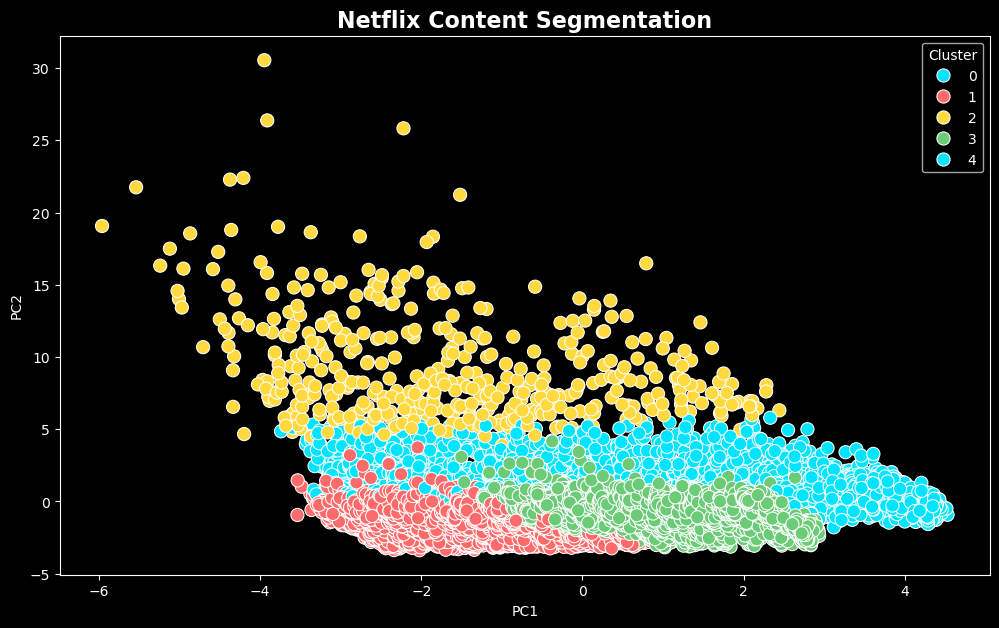

In [51]:
plt.style.use('dark_background')

plt.figure(figsize=(12,7))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette=['#00E5FF', '#FF6B6B', '#FFD93D', '#6BCB77'],
    s=90
)

plt.title('Netflix Content Segmentation', fontsize=16, fontweight='bold')
plt.show()

### PCA Cluster Visualization Insights
* Distinct cluster groups are visible, indicating that the clustering algorithm successfully segmented Netflix content into different categories.
* Some overlap between clusters exists, suggesting that certain titles share similar characteristics.
* Clusters with dense points represent large content segments with common features.
* Scattered points may indicate unique or niche content that differs from the majority of titles.
* The PCA plot confirms that the clustering model captured meaningful patterns in popularity, ratings, revenue, and release year.

## 21. Cluster Profiling

In [52]:
cluster_profile = (

    df.groupby(
        'KMeans_Cluster'
    )[features]

    .mean()

)

In [53]:
cluster_profile

,release_year,duration,popularity,vote_count,vote_average,budget,revenue,added_year,genre_count
KMeans_Cluster,,,,,,,,,
0,2021.918699,1.0,23.605857,304.229069,5.588698,3.849452e+06,6.510133e+06,2021.918699,2.257453
1,2013.418928,1.0,72.200238,83.212405,4.666630,1.793055e+06,5.814204e+06,2013.418928,1.731052
2,2016.403888,1.0,102.700346,9645.058315,6.908110,1.398977e+08,5.204717e+08,2016.403888,3.177106
3,2021.284177,1.0,59.001992,117.461139,6.004105,6.278621e+06,2.401508e+07,2021.284177,1.895685
4,2013.937756,1.0,13.961128,572.029982,6.271291,5.781084e+06,1.253720e+07,2013.937756,2.401163


### Cluster 0 – Trending & Highly Engaged Content
* Recently released titles with strong audience interest.
* High popularity and large number of votes indicate widespread viewer engagement.
* Represents trending movies and TV shows currently attracting attention.
* Suitable for recommendation and promotional campaigns.
### Cluster 1 – Classic & Stable Content
* Older titles with consistent audience appreciation.
* Moderate ratings and engagement suggest long-term viewer interest.
* Includes evergreen content that remains relevant over time.
* Valuable for maintaining a diverse content library.
### Cluster 2 – Premium & High-Value Content
* High-budget productions with strong revenue performance.
* Often includes blockbuster movies and flagship series.
* Represents Netflix's most commercially successful content.
* Useful for understanding investment returns and content strategy.
### Cluster 3 – Low Engagement Content
* Lower popularity, fewer votes, and limited audience interaction.
* Content may have niche appeal or low visibility.
* Represents underperforming titles within the catalog.
* Can help identify content requiring marketing support or review.
### Cluster 4 – Niche & Specialized Content
* Targets specific audience interests rather than mass appeal.
* May have moderate ratings but lower overall popularity.
* Includes unique genres, regional content, or specialized themes.
* Important for audience diversity and personalized recommendations.
### Overall Insight

* The clustering analysis successfully segmented Netflix content into Trending, Classic, Premium, Low-Engagement, and Niche categories, enabling better content understanding, recommendation strategies, audience targeting, and business decision-making.   

## 22. Save Pipeline

In [55]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")

print("Models saved successfully!")

Models saved successfully!


## 23. Save Final Dataset

In [57]:
df.to_csv(
    "netflix_clustered.csv",
    index=False
)

## Business Problem

* Netflix has thousands of titles. Understanding hidden content groups helps:

* Recommendation Systems
* Content Investment
* Marketing Strategy
* Audience Segmentation
* Best Model

### Compare:

* Model	* Silhouette	* DB Index
* KMeans* Highest	    * Lowest
* Hierarchical	* Moderate	* Moderate
* DBSCAN	Useful for Noise Detection	Variable
## Final Outcome

* The model automatically segments 32,000 Netflix titles into meaningful content groups based on popularity, ratings, duration, release year, revenue, and audience engagement metrics.